# НИРС по анализу данных.

## Построение модели машинного обучения для решения задач классификации и регрессии.

В качестве набора данных мы будем использовать набор данных 
по ожирению у людей - https://www.kaggle.com/datasets/adeniranstephen/obesity-prediction-dataset?resource=download

Эта задача является очень актуальной в условиях современности: мировые правительства (министерства здоровья РФ, ЕС, США в особенности) очень озабочены проблемой ожирения населения даже с самого малого возраста. В связи с этим я берусь за задачу построения модели, которая выявит тенденции и найдет наибольшие предикторы ожирения.

Датасет состоит из трех файлов:
- obesity_train.csv - обучающая выборка
- obesity_train.csv - тестовая выборка
- obesity_train_full.csv - полный датасет для теста

Каждый файл содержит следующие колонки:
- Gender (Пол) - бинарный признак: Male (мужской), Female (женский).
- Age (Возраст) - возраст человека в годах.
- Height (Рост) - рост в метрах.
- Weight (Вес) - вес в килограммах.
- family_history_with_overweight (Наличие семейной истории избыточного веса) - yes/no (да/нет).
- FAVC (Частое употребление высококалорийной пищи) - yes/no (да/нет).
- FCVC (Частота употребления овощей) - числовое значение (шкала от 1 до 3).
- NCP (Количество основных приемов пищи в день) - числовое значение (например, 1-4).
- CAEC (Употребление пищи между приемами пищи) - категориальный признак: Sometimes (иногда), Frequently (часто), no (нет) и др.
- SMOKE (Курение) - yes/no (да/нет).
- CH2O (Потребление воды в день) - числовое значение (шкала 1-3).
- SCC (Мониторинг потребления калорий) - yes/no (да/нет).
- FAF (Физическая активность в неделю) - числовое значение (шкала 0-3).
- TUE (Время использования электронных устройств) - числовое значение (шкала 0-3).
- CALC (Употребление алкоголя) - категориальный признак: Sometimes (иногда), Frequently (часто), no (нет).
- MTRANS (Способ передвижения) - категориальный признак: Public_Transportation (общественный транспорт), Walking (ходьба), Automobile (автомобиль), Motorbike (мотоцикл).
- Obesity (Уровень ожирения) - целевая переменная, категориальный признак: Normal_Weight (нормальный вес), Overweight_Level_I (избыточный вес I степени), Overweight_Level_II (избыточный вес II степени) и др.

В рассматриваемом примере будем решать обе задачи - и задачу классификации, и задачу регрессии:
- Для решения **задачи классификации** в качестве целевого признака будем использовать "Obesity".
- Для решения **задачи регрессии** в качестве целевого признака будем использовать "BMI" - индекс массы тела Weight / (Height^2), который вычислим для датасета позже.

### Импорт библиотек
Импортируем библиотеки с помощью команды import. Как правило, все команды import размещают в первых ячейках ноутбука.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_squared_log_error, median_absolute_error, r2_score 
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.svm import SVC, NuSVC, LinearSVC, OneClassSVM, SVR, NuSVR, LinearSVR
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, export_graphviz
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.ensemble import ExtraTreesClassifier, ExtraTreesRegressor
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
%matplotlib inline 
sns.set(style="ticks")

### Загрузка данных

Загрузим файлы датасета в помощью библиотеки Pandas. 

In [2]:
# Обучающая выборка
original_train = pd.read_csv('data/obesity_train.csv', sep=",")
# Тестовая выборка (два файла)
original_test_1 = pd.read_csv('data/obesity_test.csv', sep=",")
original_test_2 = pd.read_csv('data/obesity_test_full.csv', sep=",")

In [3]:
# Удалим дубликаты записей, если они присутствуют
train = original_train.drop_duplicates()
test_1 = original_test_1.drop_duplicates()
test_2 = original_test_2.drop_duplicates()

## Проведение разведочного анализа данных. Построение графиков, необходимых для понимания структуры данных. Анализ и заполнение пропусков в данных.

### Основные характеристики датасетов

In [4]:
# Первые 5 строк датасета
train.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,BMI,Obesity
0,0,21,1.63,60.00,1,1,3.0,3.00,0,1,2.00,0,2.00,0.000,2,3,22.582709,0
1,0,21,1.75,133.62,1,1,3.0,3.00,2,0,2.89,0,1.48,0.780,2,3,43.631020,1
2,0,23,1.66,82.60,1,1,1.2,1.36,2,0,2.77,0,0.13,1.659,2,3,29.975323,1
3,0,22,1.59,44.24,0,0,3.0,1.70,1,0,2.55,0,1.10,0.000,3,3,17.499308,0
4,1,26,1.81,106.04,1,1,3.0,3.00,2,0,2.86,0,1.81,0.680,2,3,32.367754,1


In [5]:
test_1.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,BMI,Obesity
0,0,20,1.76,53.7,1,1,2.0,3.89,1,0,1.86,0,2.87,2.000,3,3,17.336002,0
1,0,26,1.62,111.0,1,1,3.0,3.00,2,0,2.70,0,0.00,0.323,2,3,42.295382,1
2,1,18,1.85,60.0,1,1,3.0,4.00,2,0,2.00,1,2.00,0.000,2,0,17.531045,0
3,0,21,1.52,42.0,0,1,3.0,1.00,1,0,1.00,0,0.00,0.000,2,3,18.178670,0
4,1,22,1.75,74.0,1,0,2.0,3.00,2,0,2.00,0,1.00,2.000,2,1,24.163265,0


In [6]:
test_2.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,BMI,Obesity
0,0,20,1.76,53.7,1,1,2.0,3.89,1,0,1.86,0,2.87,2.000,3,3,17.336002,0
1,0,26,1.62,111.0,1,1,3.0,3.00,2,0,2.70,0,0.00,0.323,2,3,42.295382,1
2,1,18,1.85,60.0,1,1,3.0,4.00,2,0,2.00,1,2.00,0.000,2,0,17.531045,0
3,0,21,1.52,42.0,0,1,3.0,1.00,1,0,1.00,0,0.00,0.000,2,3,18.178670,0
4,1,22,1.75,74.0,1,0,2.0,3.00,2,0,2.00,0,1.00,2.000,2,1,24.163265,0


In [7]:
# Размер обучающего датасета - 8143 строк, 7 колонок
train.shape, test_1.shape, test_2.shape

((1043, 18), (421, 18), (2067, 18))

In [8]:
# Список колонок
train.columns

Index(['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight',
       'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE',
       'CALC', 'MTRANS', 'BMI', 'Obesity'],
      dtype='object')

In [9]:
# Список колонок с типами данных 
# убедимся что типы данных одинаковы в обучающей и тестовых выборках
train.dtypes

Gender                              int64
Age                                 int64
Height                            float64
Weight                            float64
family_history_with_overweight      int64
FAVC                                int64
FCVC                              float64
NCP                               float64
CAEC                                int64
SMOKE                               int64
CH2O                              float64
SCC                                 int64
FAF                               float64
TUE                               float64
CALC                                int64
MTRANS                              int64
BMI                               float64
Obesity                             int64
dtype: object

In [10]:
test_1.dtypes

Gender                              int64
Age                                 int64
Height                            float64
Weight                            float64
family_history_with_overweight      int64
FAVC                                int64
FCVC                              float64
NCP                               float64
CAEC                                int64
SMOKE                               int64
CH2O                              float64
SCC                                 int64
FAF                               float64
TUE                               float64
CALC                                int64
MTRANS                              int64
BMI                               float64
Obesity                             int64
dtype: object

In [11]:
test_2.dtypes

Gender                              int64
Age                                 int64
Height                            float64
Weight                            float64
family_history_with_overweight      int64
FAVC                                int64
FCVC                              float64
NCP                               float64
CAEC                                int64
SMOKE                               int64
CH2O                              float64
SCC                                 int64
FAF                               float64
TUE                               float64
CALC                                int64
MTRANS                              int64
BMI                               float64
Obesity                             int64
dtype: object

In [12]:
# Проверим наличие пустых значений
train.isnull().sum()

Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
BMI                               0
Obesity                           0
dtype: int64

In [13]:
test_1.isnull().sum()

Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
BMI                               0
Obesity                           0
dtype: int64

In [14]:
test_2.isnull().sum()

Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
BMI                               0
Obesity                           0
dtype: int64

**Вывод. Представленный набор данных не содержит пропусков ни в обучающей, ни в тестовой выборках.**

### Построение графиков для понимания структуры данных

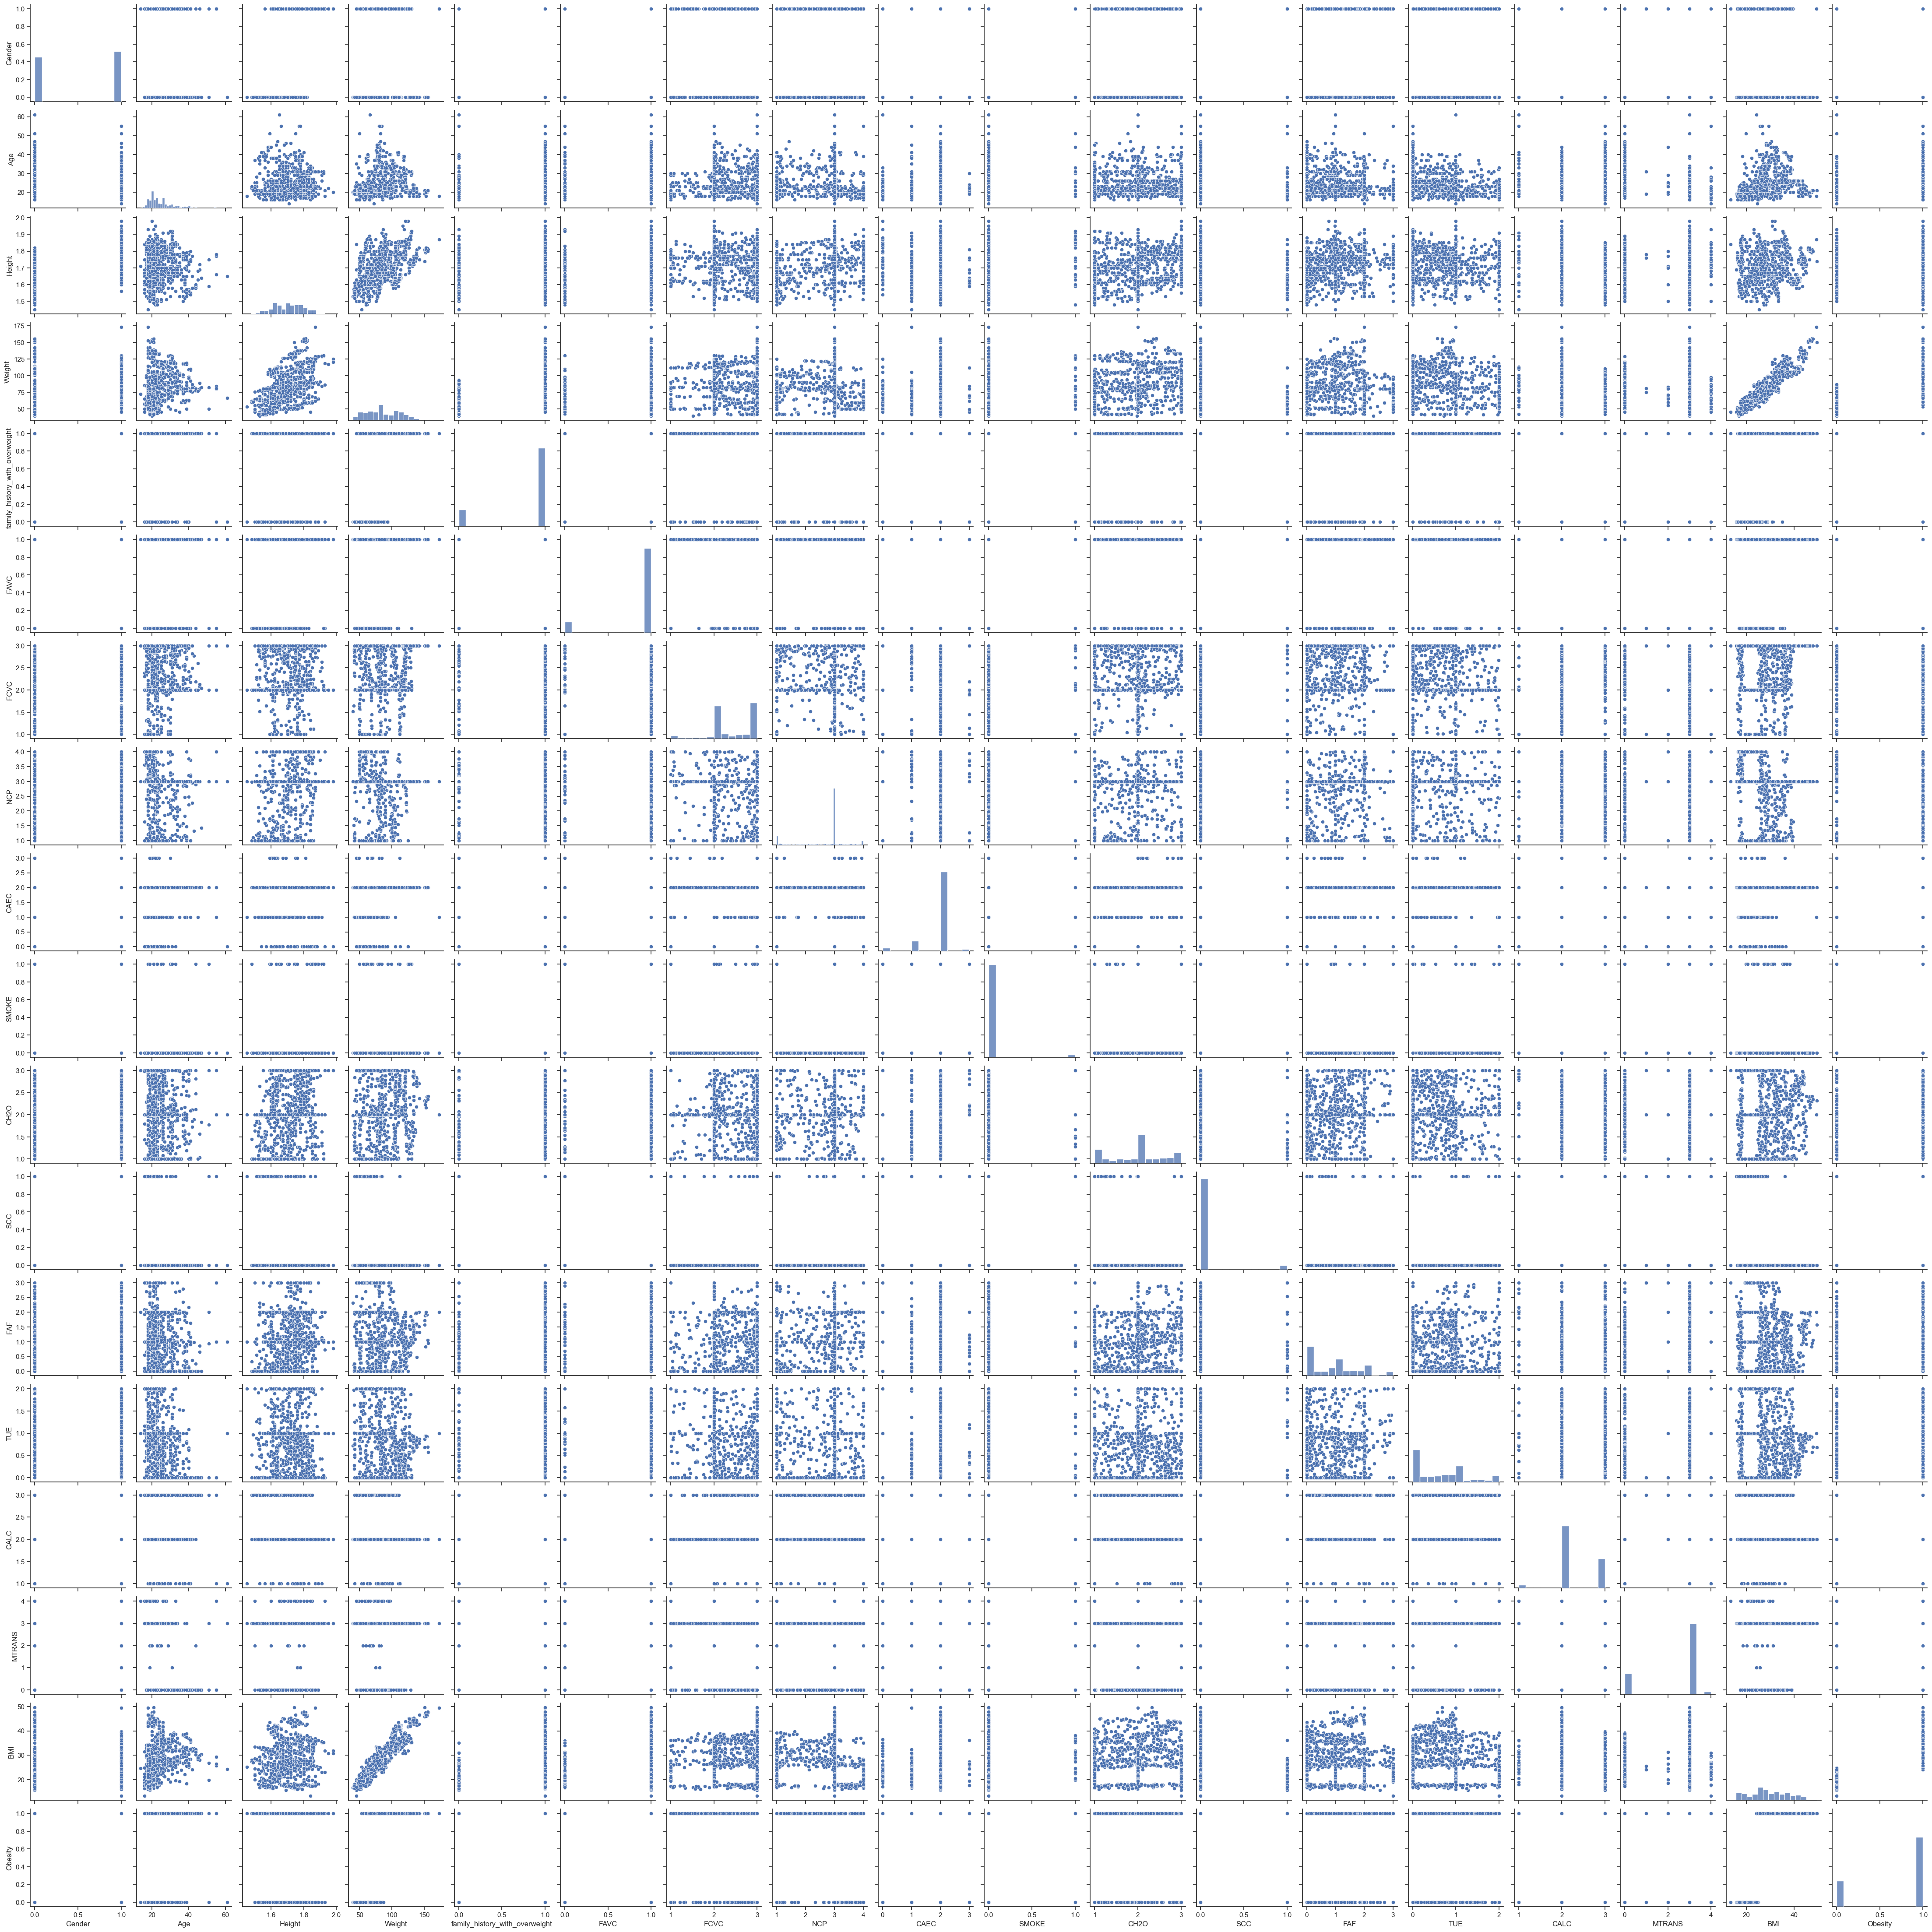

In [15]:
# Парные диаграммы
sns.pairplot(train)

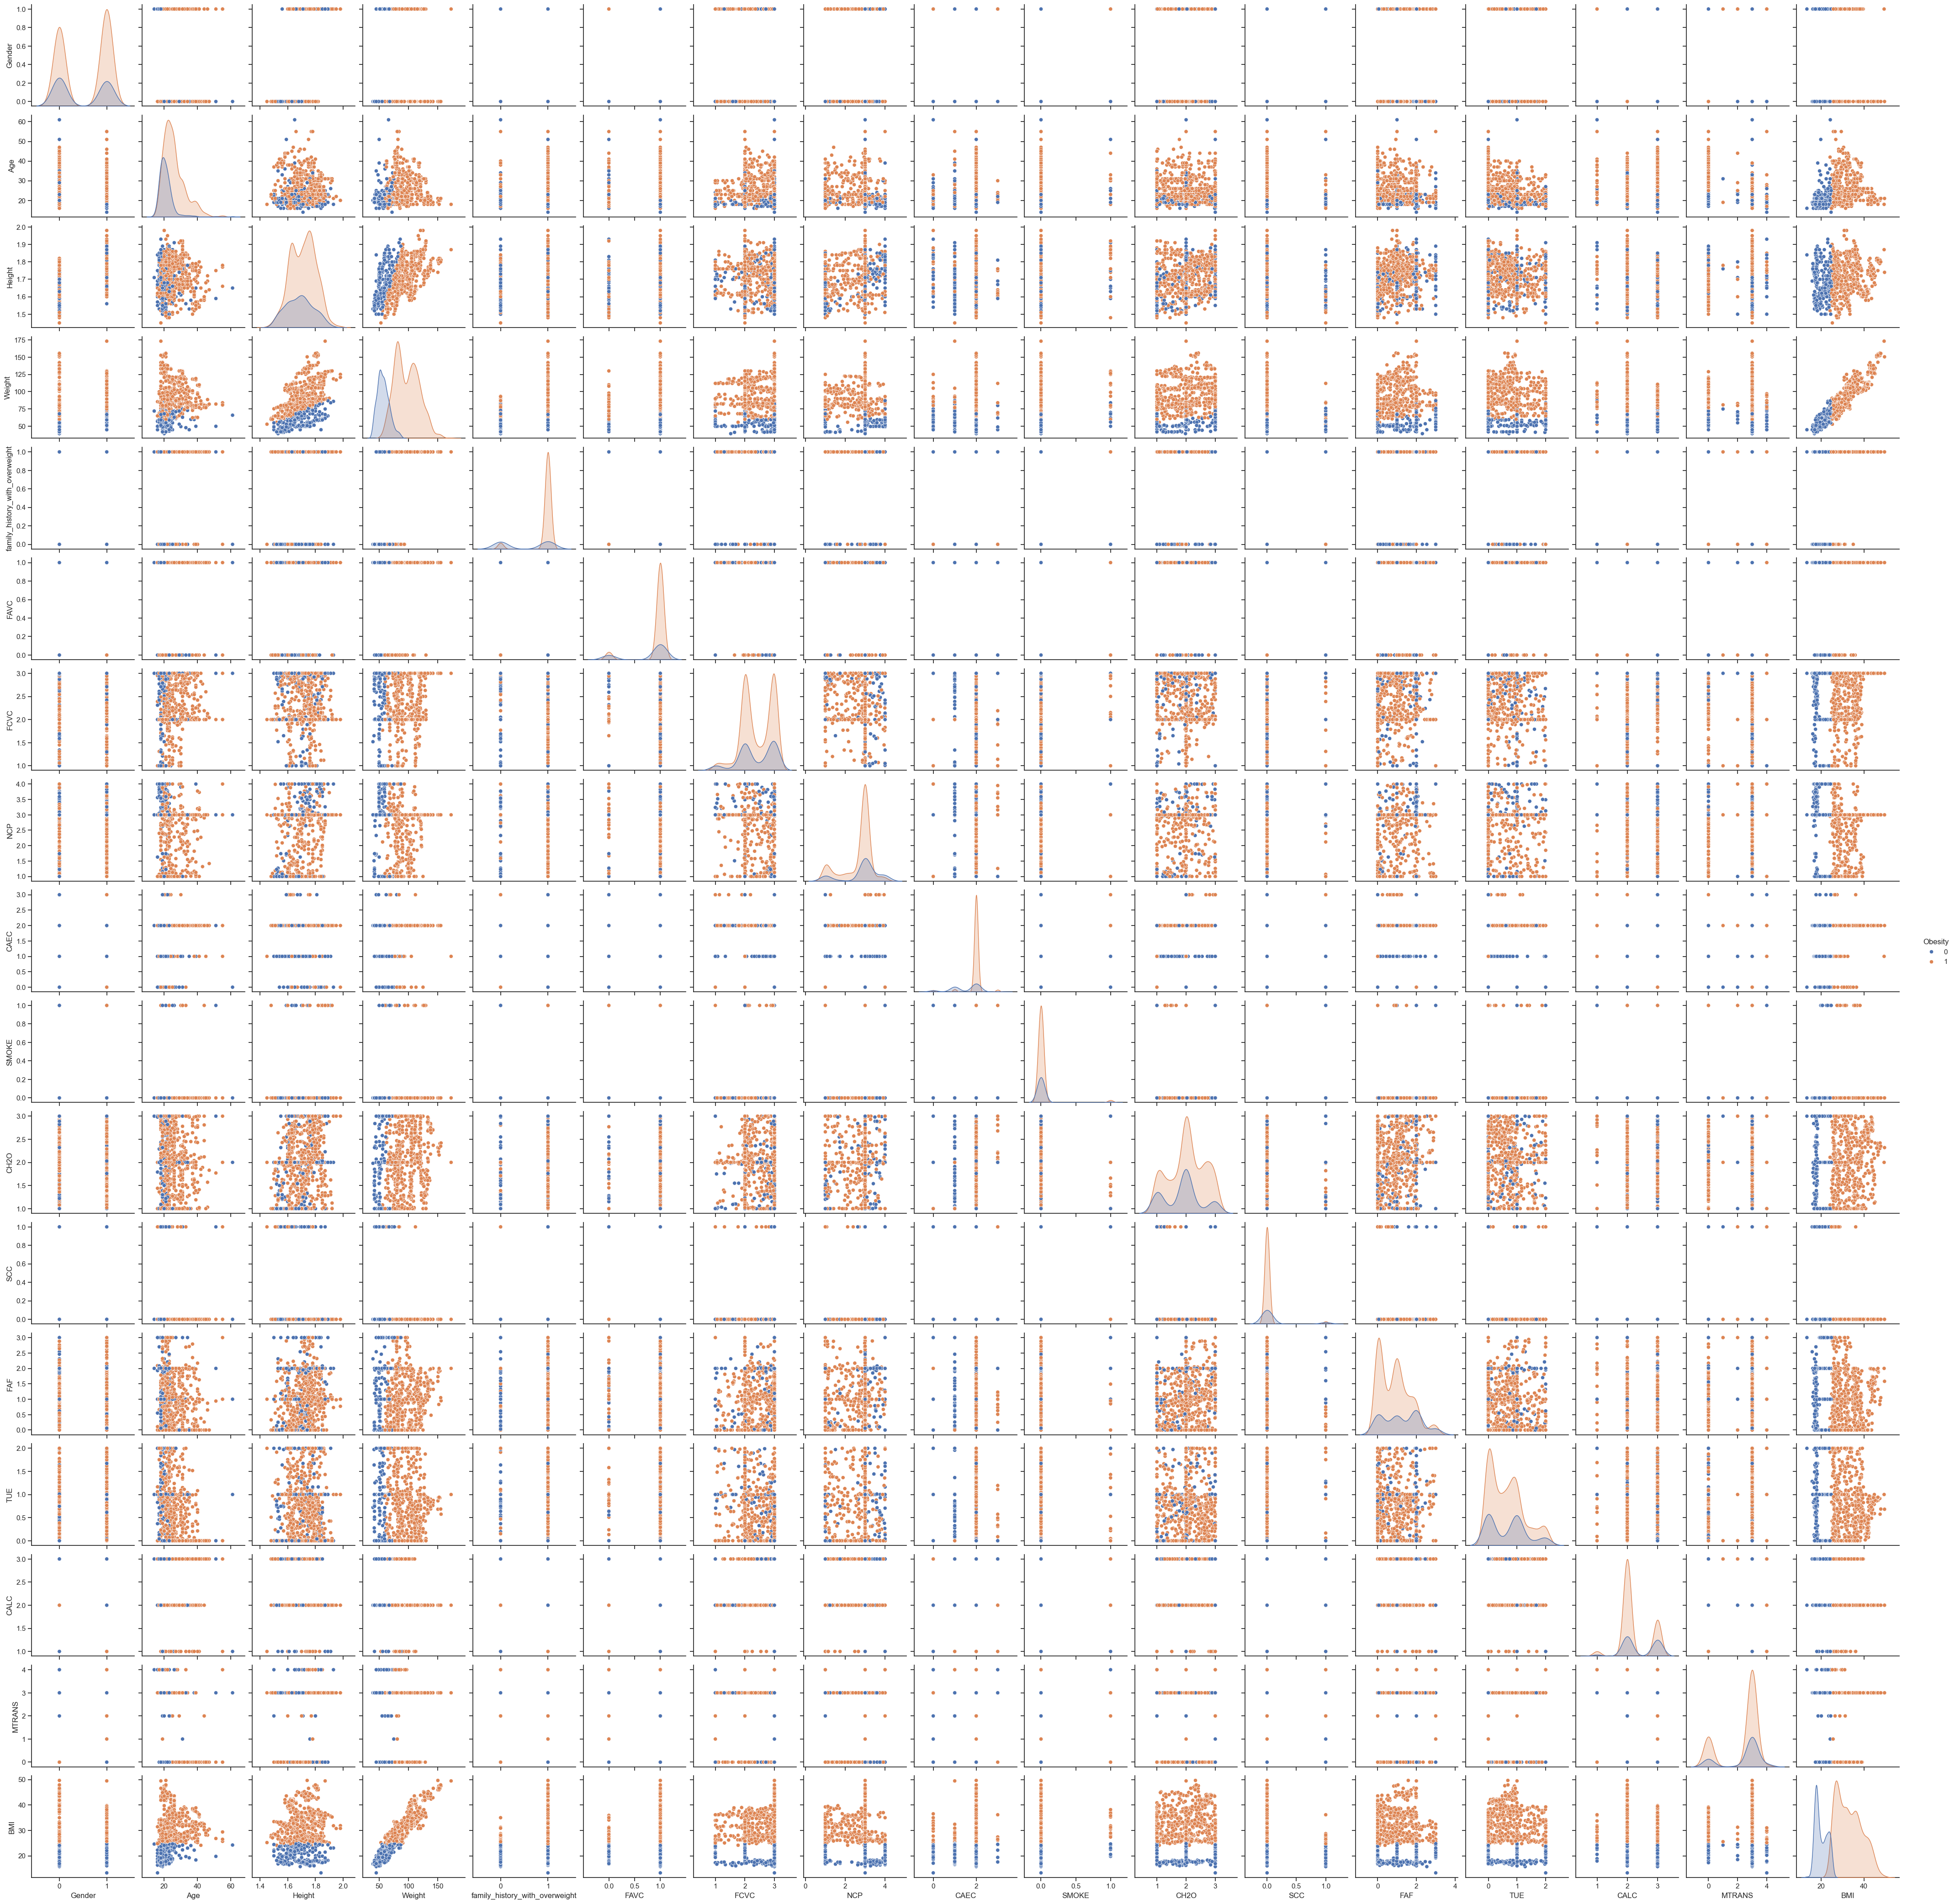

In [16]:
sns.pairplot(train, hue="Obesity")

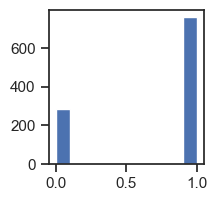

In [17]:
# Оценим дисбаланс классов для Occupancy
fig, ax = plt.subplots(figsize=(2,2)) 
plt.hist(train['Obesity'])
plt.show()

In [18]:
train['Obesity'].value_counts()

Obesity
1    761
0    282
Name: count, dtype: int64

In [19]:
# посчитаем дисбаланс классов
total = train.shape[0]
classes = []
class_n=0
for item in train['Obesity'].value_counts():
    classes.append(item)
    print('Класс {} составляет {}%.'
      .format(class_n+1, round(classes[class_n] / total, 4)*100))
    class_n+=1
classes

Класс 1 составляет 72.96000000000001%.
Класс 2 составляет 27.04%.


[761, 282]

**Вывод. Дисбаланс классов присутствует, но является приемлемым.**

In [20]:
train.columns

Index(['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight',
       'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE',
       'CALC', 'MTRANS', 'BMI', 'Obesity'],
      dtype='object')

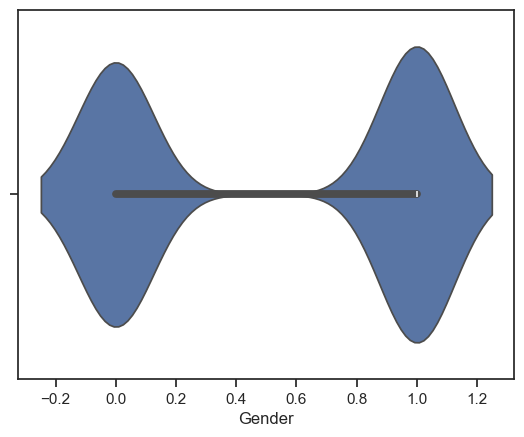

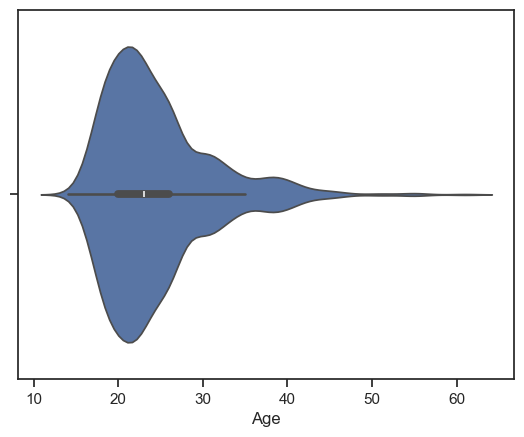

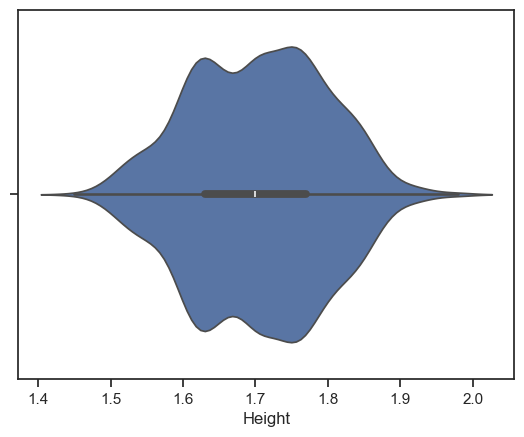

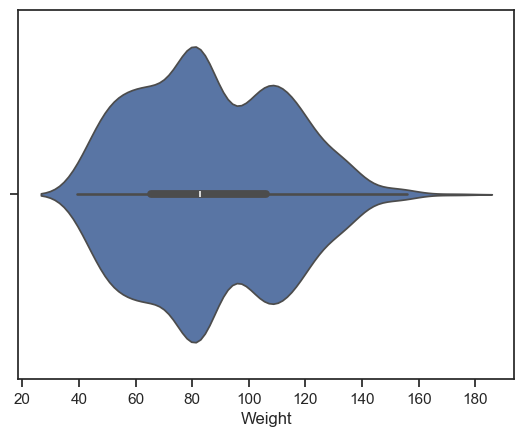

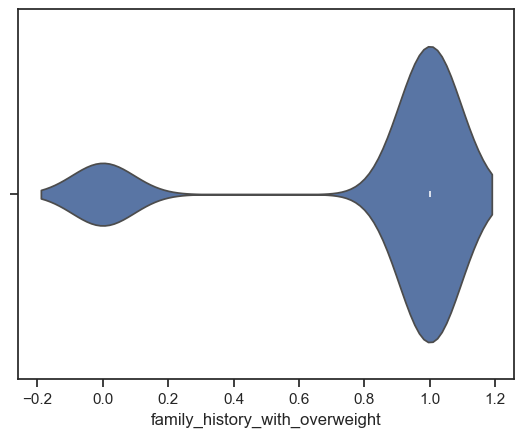

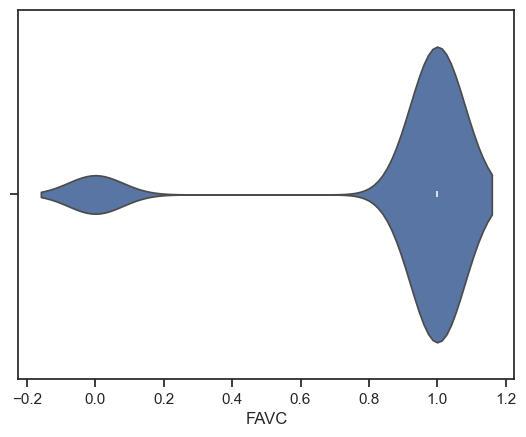

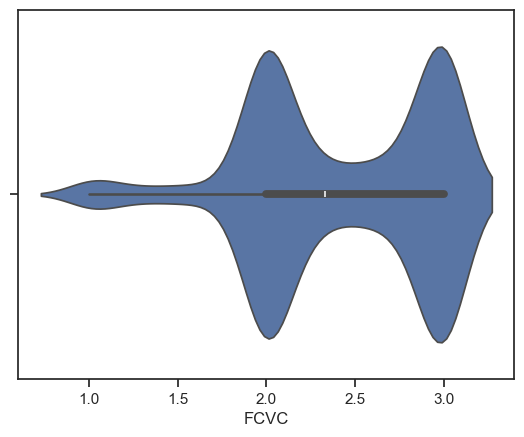

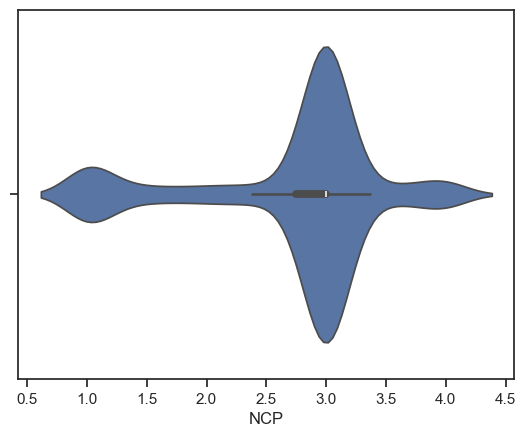

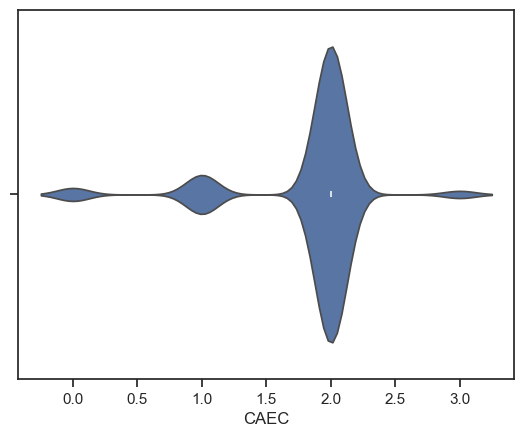

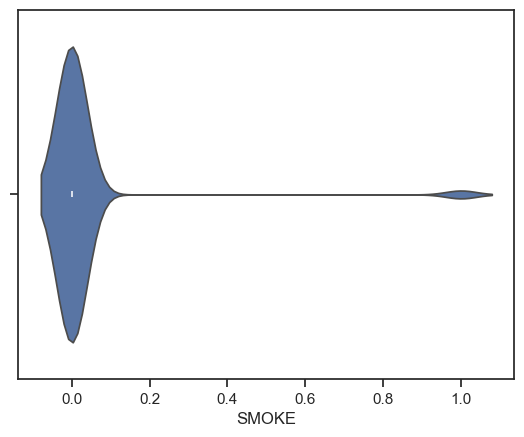

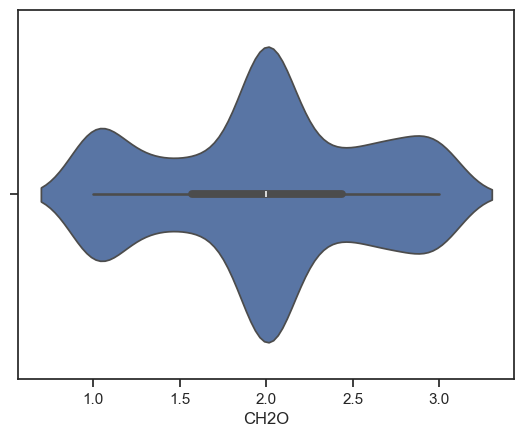

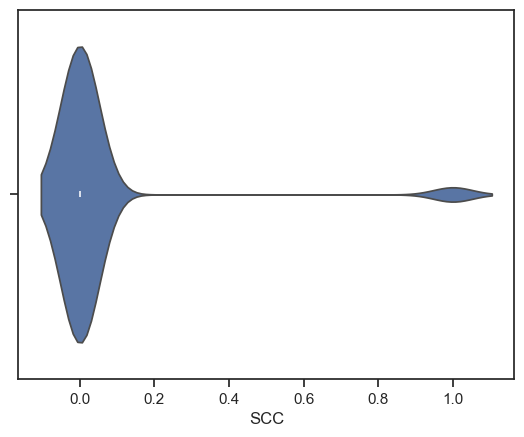

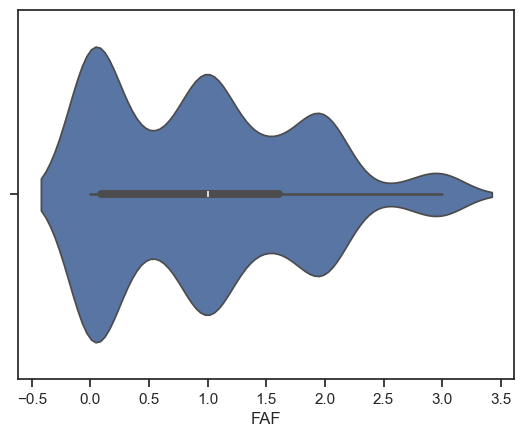

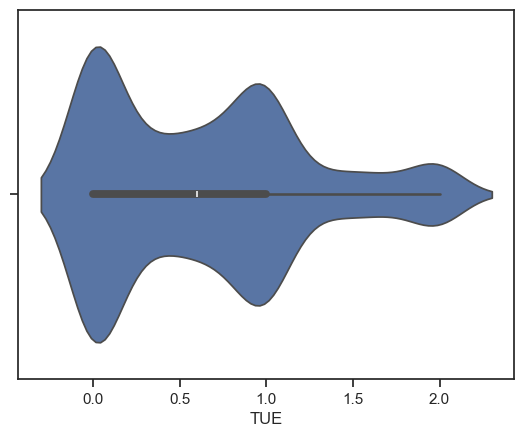

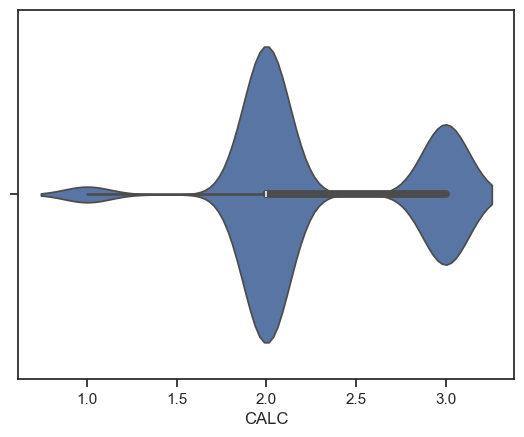

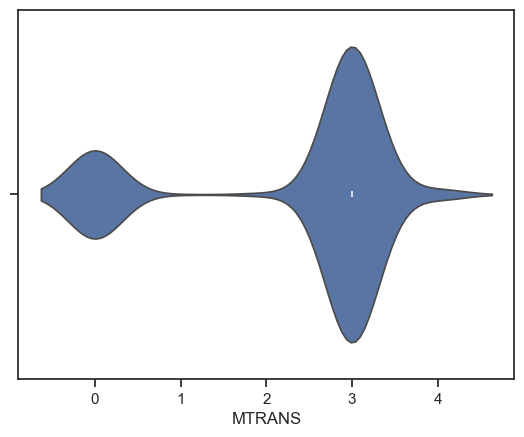

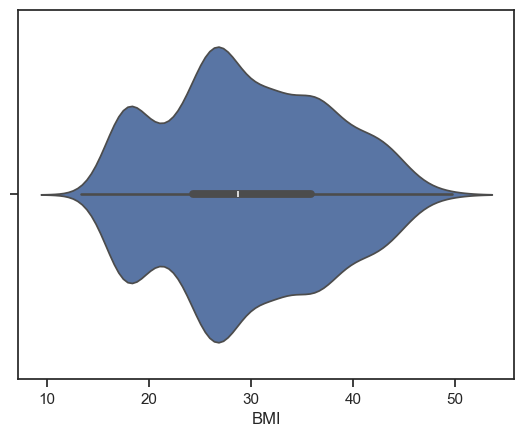

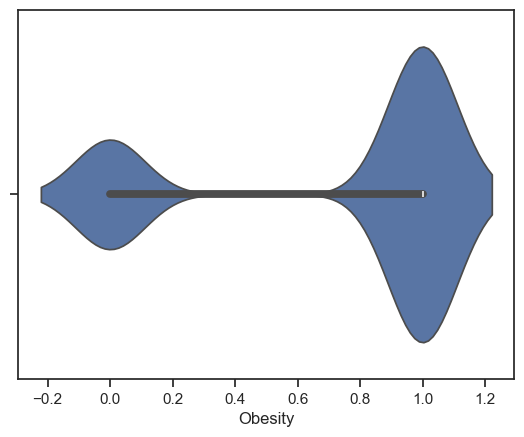

In [21]:
# Скрипичные диаграммы для числовых колонок
for col in ['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight',
       'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE',
       'CALC', 'MTRANS', 'BMI', 'Obesity']:
    sns.violinplot(x=train[col])
    plt.show()

## Выбор признаков, подходящих для построения моделей. Кодирование категориальных признаков. Масштабирование данных. Формирование вспомогательных признаков, улучшающих качество моделей.

In [22]:
train.dtypes

Gender                              int64
Age                                 int64
Height                            float64
Weight                            float64
family_history_with_overweight      int64
FAVC                                int64
FCVC                              float64
NCP                               float64
CAEC                                int64
SMOKE                               int64
CH2O                              float64
SCC                                 int64
FAF                               float64
TUE                               float64
CALC                                int64
MTRANS                              int64
BMI                               float64
Obesity                             int64
dtype: object

Для построения моделей будем использовать все признаки кроме признака date, потому что мы не рассматриваем наши данные как временной ряд.

Категориальные признаки отсутствуют, их кодирования не требуется. Исключением является признак Occupancy, но в представленном датасете  он уже закодирован на основе подхода LabelEncoding.

Вспомогательные признаки для улучшения качества моделей в данном примере мы строить не будем.

Выполним масштабирование данных. Для этого необходимо объединить обучающую и тестовые выборки.

In [23]:
# Создадим вспомогательные колонки, 
# чтобы наборы данных можно было разделить.
train['dataset'] = 'TRAIN'
test_1['dataset'] = 'TEST1'
test_2['dataset'] = 'TEST2'

C:\Users\borizzler\AppData\Local\Temp\ipykernel_13824\219576936.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['dataset'] = 'TRAIN'
C:\Users\borizzler\AppData\Local\Temp\ipykernel_13824\219576936.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_1['dataset'] = 'TEST1'
C:\Users\borizzler\AppData\Local\Temp\ipykernel_13824\219576936.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See th

In [24]:
# Колонки для объединения
join_cols = ['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight',
       'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE',
       'CALC', 'MTRANS', 'BMI', 'Obesity', 'dataset']

In [25]:
data_all = pd.concat([train[join_cols], test_1[join_cols], test_2[join_cols]])

In [26]:
# Проверим корректность объединения
assert data_all.shape[0] == train.shape[0]+test_1.shape[0]+test_2.shape[0]

In [27]:
data_all.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,BMI,Obesity,dataset
0,0,21,1.63,60.00,1,1,3.0,3.00,0,1,2.00,0,2.00,0.000,2,3,22.582709,0,TRAIN
1,0,21,1.75,133.62,1,1,3.0,3.00,2,0,2.89,0,1.48,0.780,2,3,43.631020,1,TRAIN
2,0,23,1.66,82.60,1,1,1.2,1.36,2,0,2.77,0,0.13,1.659,2,3,29.975323,1,TRAIN
3,0,22,1.59,44.24,0,0,3.0,1.70,1,0,2.55,0,1.10,0.000,3,3,17.499308,0,TRAIN
4,1,26,1.81,106.04,1,1,3.0,3.00,2,0,2.86,0,1.81,0.680,2,3,32.367754,1,TRAIN


In [28]:
# Числовые колонки для масштабирования
scale_cols = ['Height', 'Weight', 
       'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE',
       'CALC', 'MTRANS']

In [29]:
sc1 = MinMaxScaler()
sc1_data = sc1.fit_transform(data_all[scale_cols])

In [30]:
# Добавим масштабированные данные в набор данных
for i in range(len(scale_cols)):
    col = scale_cols[i]
    new_col_name = col + '_scaled'
    data_all[new_col_name] = sc1_data[:,i]

In [31]:
data_all.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,...,dataset,Height_scaled,Weight_scaled,FCVC_scaled,NCP_scaled,CH2O_scaled,FAF_scaled,TUE_scaled,CALC_scaled,MTRANS_scaled
0,0,21,1.63,60.00,1,1,3.0,3.00,0,1,...,TRAIN,0.339623,0.156716,1.0,0.666667,0.500,0.666667,0.0000,0.666667,0.75
1,0,21,1.75,133.62,1,1,3.0,3.00,2,0,...,TRAIN,0.566038,0.706119,1.0,0.666667,0.945,0.493333,0.3900,0.666667,0.75
2,0,23,1.66,82.60,1,1,1.2,1.36,2,0,...,TRAIN,0.396226,0.325373,0.1,0.120000,0.885,0.043333,0.8295,0.666667,0.75
3,0,22,1.59,44.24,0,0,3.0,1.70,1,0,...,TRAIN,0.264151,0.039104,1.0,0.233333,0.775,0.366667,0.0000,1.000000,0.75
4,1,26,1.81,106.04,1,1,3.0,3.00,2,0,...,TRAIN,0.679245,0.500299,1.0,0.666667,0.930,0.603333,0.3400,0.666667,0.75


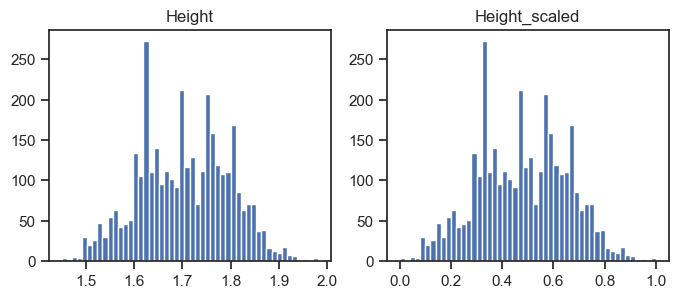

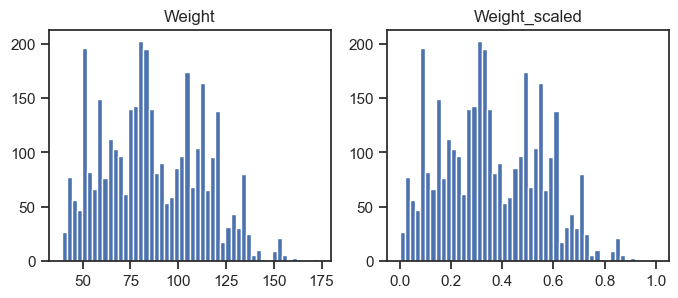

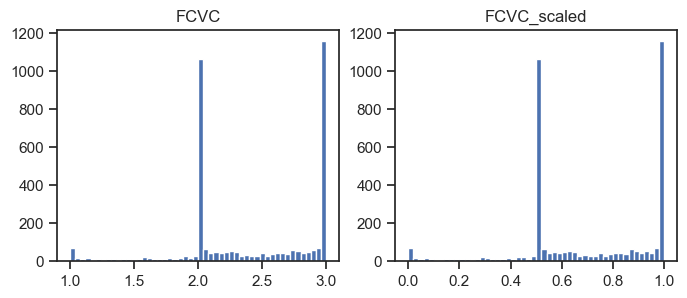

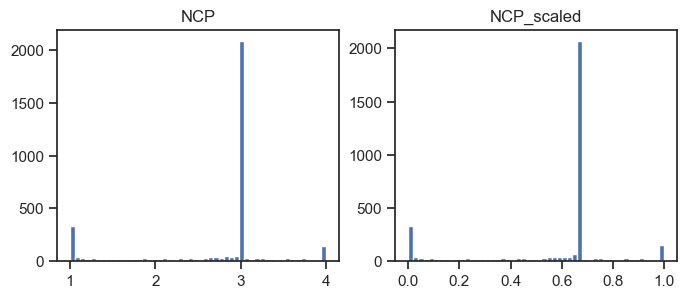

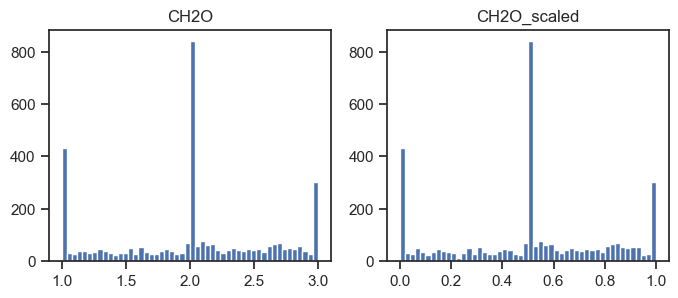

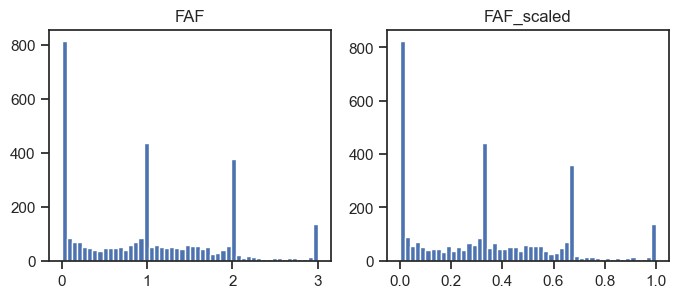

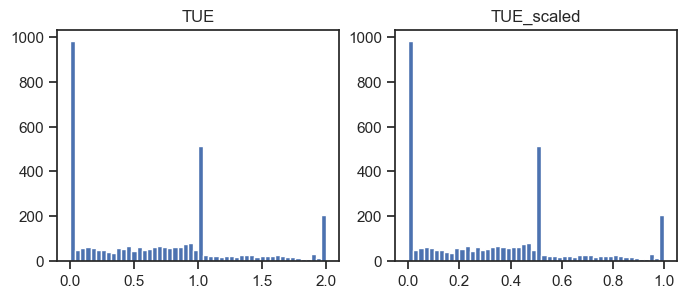

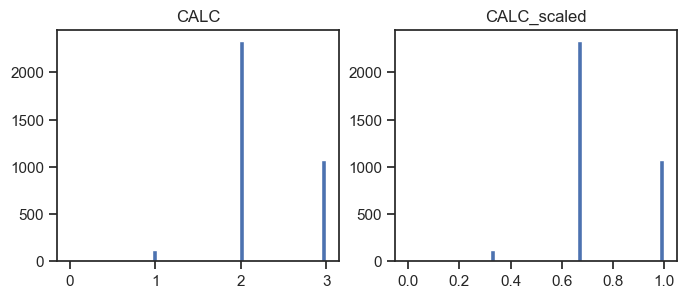

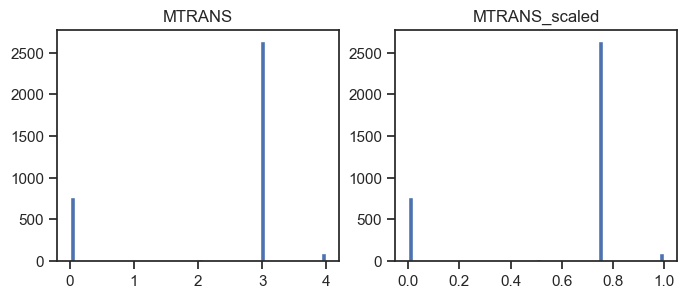

In [32]:
# Проверим, что масштабирование не повлияло на распределение данных
for col in scale_cols:
    col_scaled = col + '_scaled'

    fig, ax = plt.subplots(1, 2, figsize=(8,3))
    ax[0].hist(data_all[col], 50)
    ax[1].hist(data_all[col_scaled], 50)
    ax[0].title.set_text(col)
    ax[1].title.set_text(col_scaled)
    plt.show()

## Проведение корреляционного анализа данных. Формирование промежуточных выводов о возможности построения моделей машинного обучения. 

In [33]:
# Воспользуемся наличием тестовых выборок, 
# включив их в корреляционную матрицу
corr_cols_1 = scale_cols + ['Obesity'] + ['BMI']
corr_cols_1

['Height',
 'Weight',
 'FCVC',
 'NCP',
 'CH2O',
 'FAF',
 'TUE',
 'CALC',
 'MTRANS',
 'Obesity',
 'BMI']

In [34]:
scale_cols_postfix = [x+'_scaled' for x in scale_cols]
corr_cols_2 = scale_cols_postfix + ['Obesity'] + ['BMI']
corr_cols_2

['Height_scaled',
 'Weight_scaled',
 'FCVC_scaled',
 'NCP_scaled',
 'CH2O_scaled',
 'FAF_scaled',
 'TUE_scaled',
 'CALC_scaled',
 'MTRANS_scaled',
 'Obesity',
 'BMI']

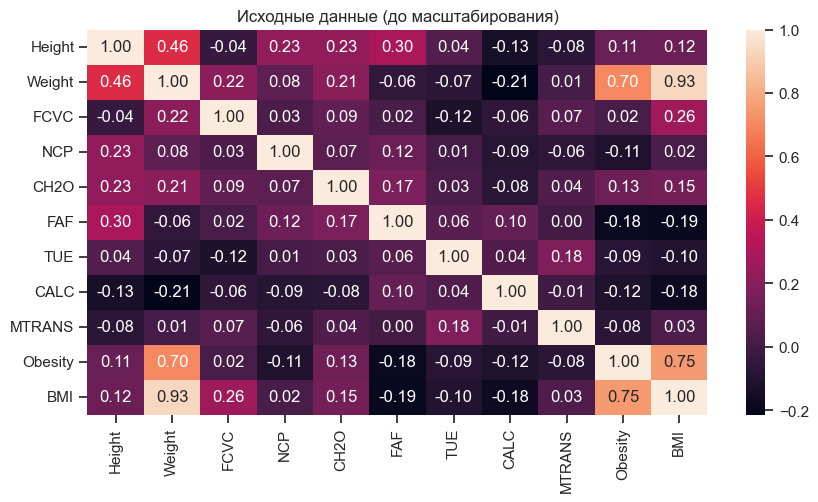

In [35]:
fig, ax = plt.subplots(figsize=(10,5))
sns.heatmap(data_all[corr_cols_1].corr(), annot=True, fmt='.2f')
ax.set_title('Исходные данные (до масштабирования)')
plt.show()

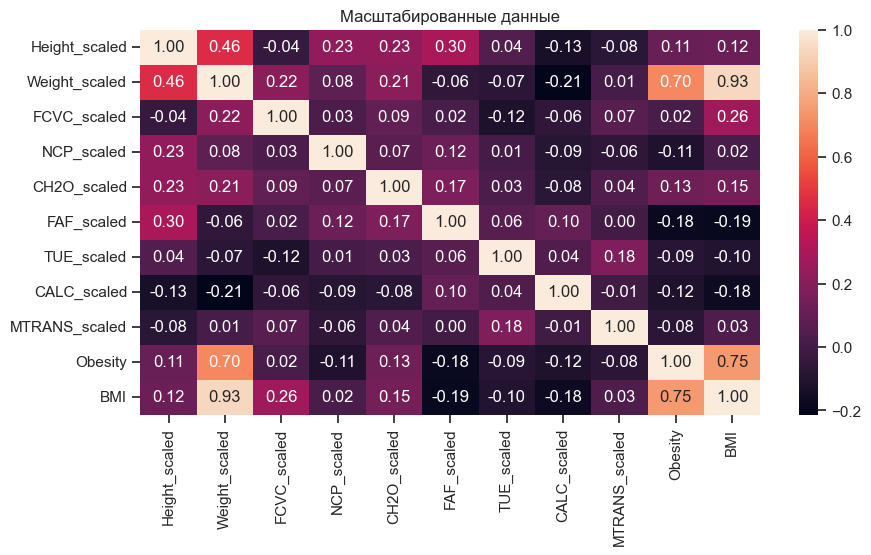

In [36]:
fig, ax = plt.subplots(figsize=(10,5))
sns.heatmap(data_all[corr_cols_2].corr(), annot=True, fmt='.2f')
ax.set_title('Масштабированные данные')
plt.show()

На основе корреляционной матрицы можно сделать следующие выводы:

- Корреляционные матрицы для исходных и масштабированных данных совпадают.
- Целевой признак классификации "Occupancy" наиболее сильно коррелирует с весом (0.70), историей семьи (0.50). Эти признаки обязательно следует оставить в модели классификации.
- Целевой признак регрессии "BMI" наиболее сильно коррелирует с теми же признаками. Эти признаки обязательно следует оставить в модели регрессии.
- Большие по модулю значения коэффициентов корреляции свидетельствуют о значимой корреляции между исходными признаками и целевым признаком.  На основании корреляционной матрицы можно сделать вывод о том, что данные позволяют построить модель машинного обучения. 

## Выбор метрик для последующей оценки качества моделей. 

### В качестве метрик для решения задачи классификации  будем использовать:

Метрики, формируемые на основе матрицы ошибок:

#### Метрика precision:

Можно переводить как точность, но такой перевод совпадает с переводом метрики "accuracy".

$precision = \frac{TP}{TP+FP}$

Доля верно предсказанных классификатором положительных объектов, из всех объектов, которые классификатор верно или неверно определил как положительные.

Используется функция [precision_score.](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_score.html#sklearn.metrics.precision_score)

#### Метрика recall (полнота):

$recall = \frac{TP}{TP+FN}$

Доля верно предсказанных классификатором положительных объектов, из всех действительно положительных объектов.

Используется функция [recall_score.](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.recall_score.html#sklearn.metrics.recall_score)

#### Метрика $F_1$-мера

Для того, чтобы объединить precision и recall в единую метрику используется $F_\beta$-мера, которая вычисляется как среднее гармоническое от precision и recall:

$F_\beta = (1+\beta^2) \cdot \frac{precision \cdot recall}{precision + recall}$

где $\beta$ определяет вес точности в метрике.

На практике чаще всего используют вариант F1-меры (которую часто называют F-мерой) при $\beta=1$:

$F_1 = 2 \cdot \frac{precision \cdot recall}{precision + recall}$

Для вычисления используется функция [f1_score.](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html#sklearn.metrics.f1_score)

#### Метрика ROC AUC

Основана на вычислении следующих характеристик:

$TPR = \frac{TP}{TP+FN}$ - True Positive Rate, откладывается по оси ординат. Совпадает с recall.

$FPR = \frac{FP}{FP+TN}$ - False Positive Rate, откладывается по оси абсцисс. Показывает какую долю из объектов отрицательного класса алгоритм предсказал неверно.

Идеальная ROC-кривая проходит через точки (0,0)-(0,1)-(1,1), то есть через верхний левый угол графика.

Чем сильнее отклоняется кривая от верхнего левого угла графика, тем хуже качество классификации.

В качестве количественной метрики используется площадь под кривой - ROC AUC (Area Under the Receiver Operating Characteristic Curve). Чем ниже проходит кривая тем меньше ее площадь и тем хуже качество классификатора.

Для получения ROC AUC используется функция [roc_auc_score.](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html#sklearn.metrics.roc_auc_score)

### В качестве метрик для решения задачи регрессии будем использовать:

#### [Mean absolute error](https://en.wikipedia.org/wiki/Mean_absolute_error) - средняя абсолютная ошибка

$MAE(y,\hat{y}) = \frac{1}{N} \cdot \sum\limits_{i=1}^N \lvert  y_i - \hat{y_i} \rvert $

где:
- $y$ - истинное значение целевого признака
- $\hat{y}$ - предсказанное значение целевого признака
- $N$ - размер тестовой выборки

Чем ближе значение к нулю, тем лучше качество регрессии.

Основная проблема метрики состоит в том, что она не нормирована.

Вычисляется с помощью функции [mean_absolute_error.](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_absolute_error.html#sklearn.metrics.mean_absolute_error)

#### [Mean squared error](https://en.wikipedia.org/wiki/Mean_squared_error) - средняя квадратичная ошибка

$MSE(y,\hat{y}) = \frac{1}{N} \cdot \sum\limits_{i=1}^N ( y_i - \hat{y_i} )^2 $

где:
- $y$ - истинное значение целевого признака
- $\hat{y}$ - предсказанное значение целевого признака
- $N$ - размер тестовой выборки

Вычисляется с помощью функции [mean_squared_error.](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html#sklearn.metrics.mean_squared_error)

#### [Метрика $R^2$ или коэффициент детерминации](https://ru.wikipedia.org/wiki/%D0%9A%D0%BE%D1%8D%D1%84%D1%84%D0%B8%D1%86%D0%B8%D0%B5%D0%BD%D1%82_%D0%B4%D0%B5%D1%82%D0%B5%D1%80%D0%BC%D0%B8%D0%BD%D0%B0%D1%86%D0%B8%D0%B8) 

$R^2(y,\hat{y}) = 1 - \frac{\sum\limits_{i=1}^N ( y_i - \hat{y_i} )^2}{\sum\limits_{i=1}^N ( y_i - \overline{y_i} )^2} $

где:
- $y$ - истинное значение целевого признака
- $\hat{y}$ - предсказанное значение целевого признака
- $N$ - размер тестовой выборки
- $\overline{y_i} = \frac{1}{N} \cdot \sum\limits_{i=1}^N y_i $

Вычисляется с помощью функции [r2_score.](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.r2_score.html#sklearn.metrics.r2_score)

### Сохранение и визуализация метрик

Разработаем класс, который позволит сохранять метрики качества построенных моделей и реализует визуализацию метрик качества.

In [37]:
class MetricLogger:
    
    def __init__(self):
        self.df = pd.DataFrame(
            {'metric': pd.Series([], dtype='str'),
            'alg': pd.Series([], dtype='str'),
            'value': pd.Series([], dtype='float')})

    def add(self, metric, alg, value):
        """
        Добавление значения
        """
        # Удаление значения если оно уже было ранее добавлено
        self.df.drop(self.df[(self.df['metric']==metric)&(self.df['alg']==alg)].index, inplace = True)
        # Добавление нового значения
        temp_df = pd.DataFrame({'metric': [metric], 'alg': [alg], 'value': [value]})
        self.df = pd.concat([self.df, temp_df], ignore_index=True)

    def get_data_for_metric(self, metric, ascending=True):
        """
        Формирование данных с фильтром по метрике
        """
        temp_data = self.df[self.df['metric']==metric]
        temp_data_2 = temp_data.sort_values(by='value', ascending=ascending)
        return temp_data_2['alg'].values, temp_data_2['value'].values
    
    def plot(self, str_header, metric, ascending=True, figsize=(5, 5)):
        """
        Вывод графика
        """
        array_labels, array_metric = self.get_data_for_metric(metric, ascending)
        fig, ax1 = plt.subplots(figsize=figsize)
        pos = np.arange(len(array_metric))
        rects = ax1.barh(pos, array_metric,
                         align='center',
                         height=0.5, 
                         tick_label=array_labels)
        ax1.set_title(str_header)
        for a,b in zip(pos, array_metric):
            plt.text(0.5, a-0.05, str(round(b,3)), color='white')
        plt.show()    

## Выбор наиболее подходящих моделей для решения задачи классификации или регрессии.

Для задачи классификации будем использовать следующие модели:
- Логистическая регрессия
- Метод ближайших соседей
- Машина опорных векторов
- Решающее дерево
- Случайный лес
- Градиентный бустинг

Для задачи регрессии будем использовать следующие модели:
- Линейная регрессия
- Метод ближайших соседей
- Машина опорных векторов
- Решающее дерево
- Случайный лес
- Градиентный бустинг

## Формирование обучающей и тестовой выборок на основе исходного набора данных.

In [38]:
# На основе масштабированных данных выделим 
# обучающую и тестовую выборки с помощью фильтра
train_data_all = data_all[data_all['dataset']=='TRAIN']
test_data_all = data_all[data_all['dataset']=='TEST1']
train_data_all.shape, test_data_all.shape

((1043, 28), (421, 28))

In [39]:
# Признаки для задачи классификации
task_clas_cols = ['Gender', 'Age', 'Height_scaled', 'Weight_scaled', 'family_history_with_overweight',
       'FAVC', 'FCVC_scaled', 'NCP_scaled', 'CAEC', 'SMOKE', 'CH2O_scaled', 'SCC', 'FAF_scaled', 'TUE_scaled',
       'CALC_scaled', 'MTRANS_scaled', 'BMI']

In [40]:
# Выборки для задачи классификации
clas_X_train = train_data_all[task_clas_cols]
clas_X_test = test_data_all[task_clas_cols]
clas_Y_train = train_data_all['Obesity']
clas_Y_test = test_data_all['Obesity']
clas_X_train.shape, clas_X_test.shape, clas_Y_train.shape, clas_Y_test.shape

((1043, 17), (421, 17), (1043,), (421,))

In [41]:
# Признаки для задачи классификации
task_regr_cols = ['Gender', 'Age', 'Height_scaled', 'Weight_scaled', 'family_history_with_overweight',
       'FAVC', 'FCVC_scaled', 'NCP_scaled', 'CAEC', 'SMOKE', 'CH2O_scaled', 'SCC', 'FAF_scaled', 'TUE_scaled',
       'CALC_scaled', 'MTRANS_scaled', 'Obesity']

In [42]:
# Выборки для задачи регресии
regr_X_train = train_data_all[task_regr_cols]
regr_X_test = test_data_all[task_regr_cols]
regr_Y_train = train_data_all['BMI']
regr_Y_test = test_data_all['BMI']
regr_X_train.shape, regr_X_test.shape, regr_Y_train.shape, regr_Y_test.shape

((1043, 17), (421, 17), (1043,), (421,))

## Построение базового решения (baseline) для выбранных моделей без подбора гиперпараметров. Производится обучение моделей на основе обучающей выборки и оценка качества моделей на основе тестовой выборки.

### Решение задачи классификации

In [43]:
# Модели
clas_models = {'LogR': LogisticRegression(max_iter=1000), 
               'KNN_5':KNeighborsClassifier(n_neighbors=5),
               'SVC':SVC(probability=True),
               'Tree':DecisionTreeClassifier(),
               'RF':RandomForestClassifier(),
               'GB':GradientBoostingClassifier()}

In [44]:
# Сохранение метрик
clasMetricLogger = MetricLogger()

In [45]:
# Отрисовка ROC-кривой
def draw_roc_curve(y_true, y_score, ax, pos_label=1, average='micro'):
    fpr, tpr, thresholds = roc_curve(y_true, y_score, 
                                     pos_label=pos_label)
    roc_auc_value = roc_auc_score(y_true, y_score, average=average)
    #plt.figure()
    lw = 2
    ax.plot(fpr, tpr, color='darkorange',
             lw=lw, label='ROC curve (area = %0.2f)' % roc_auc_value)
    ax.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
    ax.set_xlim([0.0, 1.0])
    ax.set_xlim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title('Receiver operating characteristic')
    ax.legend(loc="lower right")

In [46]:
def clas_train_model(model_name, model, clasMetricLogger):
    model.fit(clas_X_train, clas_Y_train)
    # Предсказание значений
    Y_pred = model.predict(clas_X_test)
    # Предсказание вероятности класса "1" для roc auc
    Y_pred_proba_temp = model.predict_proba(clas_X_test)
    Y_pred_proba = Y_pred_proba_temp[:,1]
    
    precision = precision_score(clas_Y_test.values, Y_pred)
    recall = recall_score(clas_Y_test.values, Y_pred)
    f1 = f1_score(clas_Y_test.values, Y_pred)
    roc_auc = roc_auc_score(clas_Y_test.values, Y_pred_proba)
    
    clasMetricLogger.add('precision', model_name, precision)
    clasMetricLogger.add('recall', model_name, recall)
    clasMetricLogger.add('f1', model_name, f1)
    clasMetricLogger.add('roc_auc', model_name, roc_auc)

    fig, ax = plt.subplots(ncols=2, figsize=(10,5))    
    draw_roc_curve(clas_Y_test.values, Y_pred_proba, ax[0])

    # Updated confusion matrix plotting
    cm = confusion_matrix(clas_Y_test.values, Y_pred, normalize='true')
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['0','1'])
    disp.plot(cmap=plt.cm.Blues, ax=ax[1])
    
    fig.suptitle(model_name)
    plt.show()

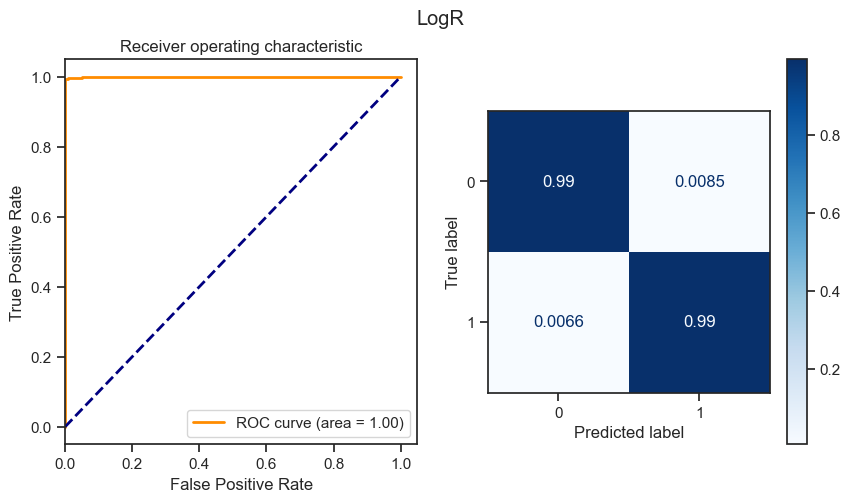

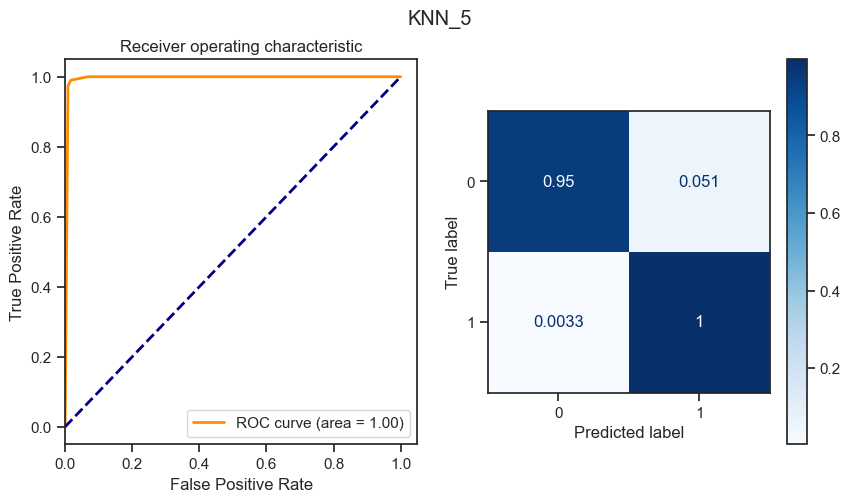

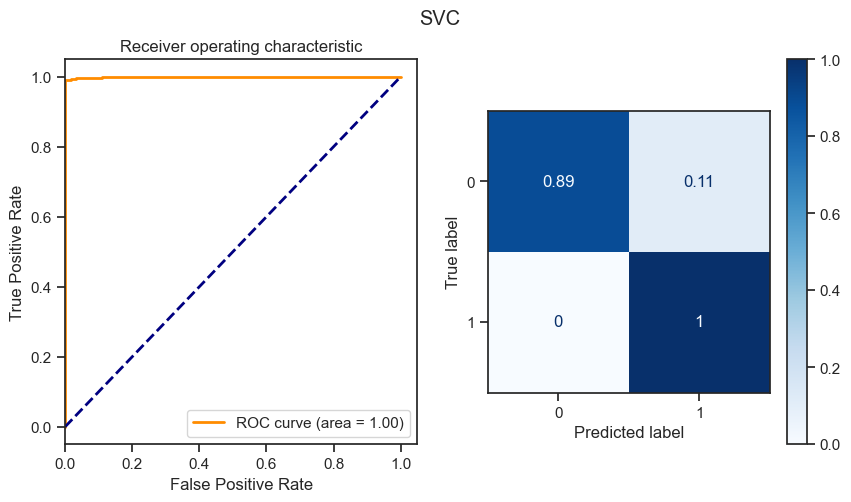

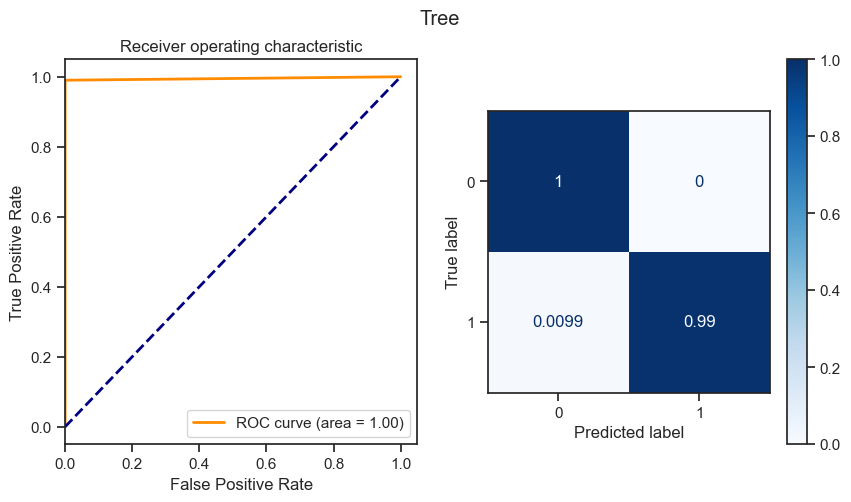

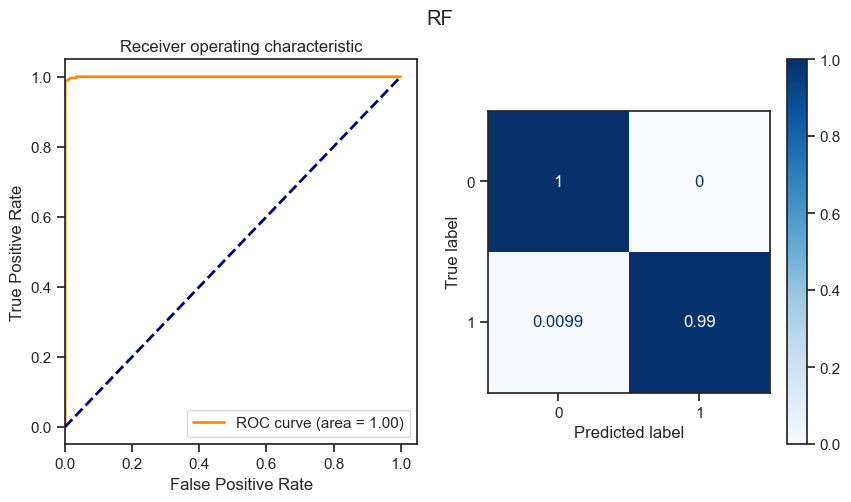

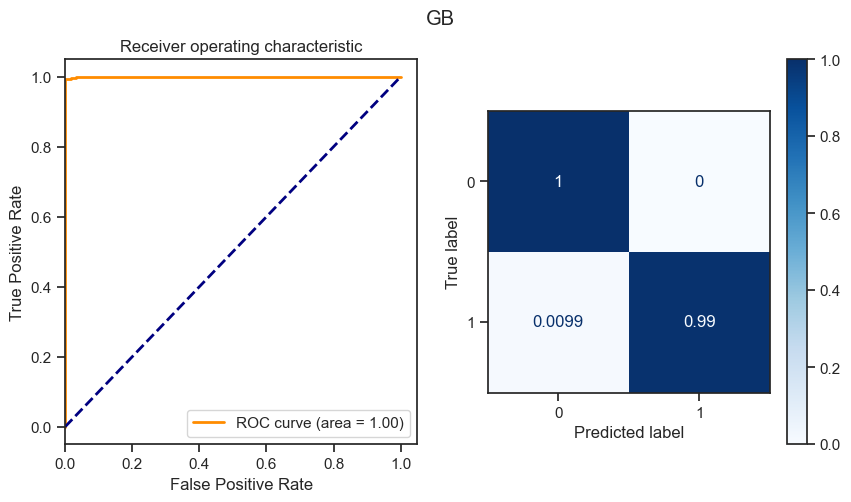

In [47]:
for model_name, model in clas_models.items():
    clas_train_model(model_name, model, clasMetricLogger)

### Решение задачи регрессии

In [48]:
# Модели
regr_models = {'LR': LinearRegression(), 
               'KNN_5':KNeighborsRegressor(n_neighbors=5),
               'SVR':SVR(),
               'Tree':DecisionTreeRegressor(),
               'RF':RandomForestRegressor(),
               'GB':GradientBoostingRegressor()}

In [49]:
# Сохранение метрик
regrMetricLogger = MetricLogger()

In [50]:
def regr_train_model(model_name, model, regrMetricLogger):
    model.fit(regr_X_train, regr_Y_train)
    Y_pred = model.predict(regr_X_test)
    
    mae = mean_absolute_error(regr_Y_test, Y_pred)
    mse = mean_squared_error(regr_Y_test, Y_pred)
    r2 = r2_score(regr_Y_test, Y_pred)

    regrMetricLogger.add('MAE', model_name, mae)
    regrMetricLogger.add('MSE', model_name, mse)
    regrMetricLogger.add('R2', model_name, r2)    
    
    print('{} \t MAE={}, MSE={}, R2={}'.format(
        model_name, round(mae, 3), round(mse, 3), round(r2, 3)))

In [51]:
for model_name, model in regr_models.items():
    regr_train_model(model_name, model, regrMetricLogger)

LR 	 MAE=0.598, MSE=0.601, R2=0.991
KNN_5 	 MAE=1.959, MSE=8.097, R2=0.878
SVR 	 MAE=5.69, MSE=50.898, R2=0.234
Tree 	 MAE=0.535, MSE=0.744, R2=0.989
RF 	 MAE=0.393, MSE=0.386, R2=0.994
GB 	 MAE=0.456, MSE=0.411, R2=0.994


## Подбор гиперпараметров для выбранных моделей. Рекомендуется использовать методы кросс-валидации. В зависимости от используемой библиотеки можно применять функцию GridSearchCV, использовать перебор параметров в цикле, или использовать другие методы.

### Пример для задачи классификации

In [52]:
clas_X_train.shape

(1043, 17)

In [53]:
n_range_list = list(range(0,1250,50))
n_range_list[0] = 1

In [54]:
n_range = np.array(n_range_list)
tuned_parameters = [{'n_neighbors': n_range}]
tuned_parameters

[{'n_neighbors': array([   1,   50,  100,  150,  200,  250,  300,  350,  400,  450,  500,
          550,  600,  650,  700,  750,  800,  850,  900,  950, 1000, 1050,
         1100, 1150, 1200])}]

In [55]:
%%time
clf_gs = GridSearchCV(KNeighborsClassifier(), tuned_parameters, cv=5, scoring='roc_auc')
clf_gs.fit(clas_X_train, clas_Y_train)

CPU times: total: 5.19 s
Wall time: 1.46 s


C:\Users\borizzler\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\model_selection\_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "C:\Users\borizzler\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\model_selection\_validation.py", line 949, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\borizzler\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_scorer.py", line 288, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid=[{'n_neighbors': array([   1,   50,  100,  150,  200,  250,  300,  350,  400,  450,  500,
        550,  600,  650,  700,  750,  800,  850,  900,  950, 1000, 1050,
       1100, 1150, 1200])}],
             scoring='roc_auc')

In [56]:
# Лучшая модель
clf_gs.best_estimator_

KNeighborsClassifier(n_neighbors=np.int64(50))

In [57]:
# Лучшее значение параметров
clf_gs.best_params_

{'n_neighbors': np.int64(50)}

In [58]:
clf_gs_best_params_txt = str(clf_gs.best_params_['n_neighbors'])
clf_gs_best_params_txt

'50'

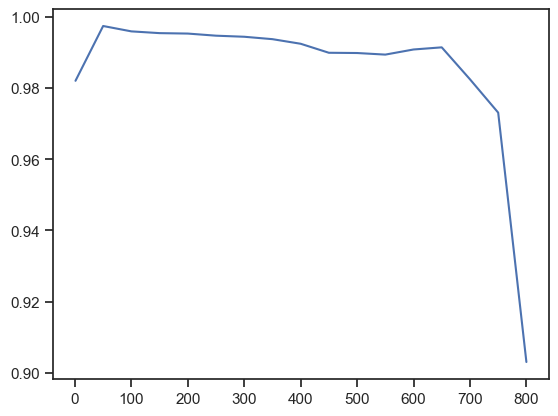

In [59]:
# Изменение качества на тестовой выборке в зависимости от К-соседей
plt.plot(n_range, clf_gs.cv_results_['mean_test_score'])

### Пример для задачи регрессии

In [60]:
n_range = np.array(range(1,2000,100))
tuned_parameters = [{'n_neighbors': n_range}]
tuned_parameters

[{'n_neighbors': array([   1,  101,  201,  301,  401,  501,  601,  701,  801,  901, 1001,
         1101, 1201, 1301, 1401, 1501, 1601, 1701, 1801, 1901])}]

In [61]:
%%time
regr_gs = GridSearchCV(KNeighborsRegressor(), tuned_parameters, cv=5, scoring='neg_mean_squared_error')
regr_gs.fit(regr_X_train, regr_Y_train)

CPU times: total: 2.58 s
Wall time: 646 ms


C:\Users\borizzler\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\model_selection\_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "C:\Users\borizzler\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\model_selection\_validation.py", line 949, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\borizzler\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_scorer.py", line 288, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^

GridSearchCV(cv=5, estimator=KNeighborsRegressor(),
             param_grid=[{'n_neighbors': array([   1,  101,  201,  301,  401,  501,  601,  701,  801,  901, 1001,
       1101, 1201, 1301, 1401, 1501, 1601, 1701, 1801, 1901])}],
             scoring='neg_mean_squared_error')

In [62]:
# Лучшая модель
regr_gs.best_estimator_

KNeighborsRegressor(n_neighbors=np.int64(1))

In [63]:
# Лучшее значение параметров
regr_gs.best_params_

{'n_neighbors': np.int64(1)}

In [64]:
regr_gs_best_params_txt = str(regr_gs.best_params_['n_neighbors'])
regr_gs_best_params_txt

'1'

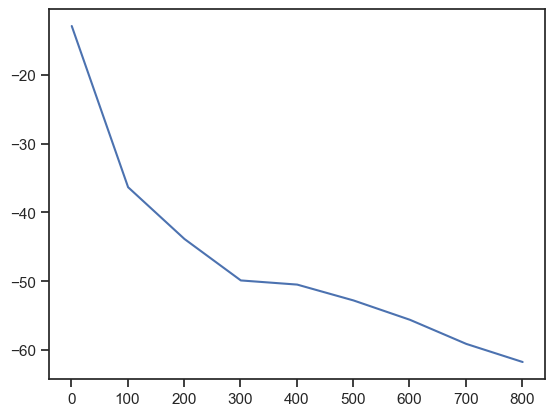

In [65]:
# Изменение качества на тестовой выборке в зависимости от К-соседей
plt.plot(n_range, regr_gs.cv_results_['mean_test_score'])

## Повторение пункта 8 для найденных оптимальных значений гиперпараметров. Сравнение качества полученных моделей с качеством baseline-моделей.

### Решение задачи классификации

In [66]:
clas_models_grid = {'KNN_5':KNeighborsClassifier(n_neighbors=5), 
                    str('KNN_' + clf_gs_best_params_txt):clf_gs.best_estimator_}

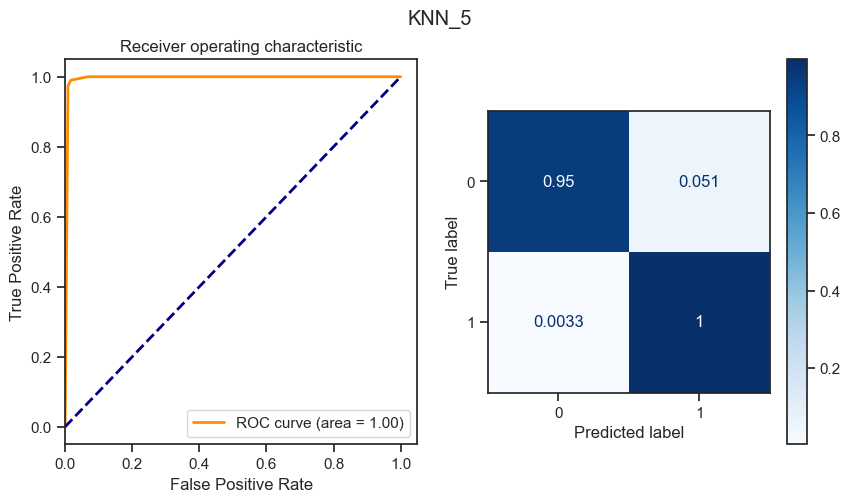

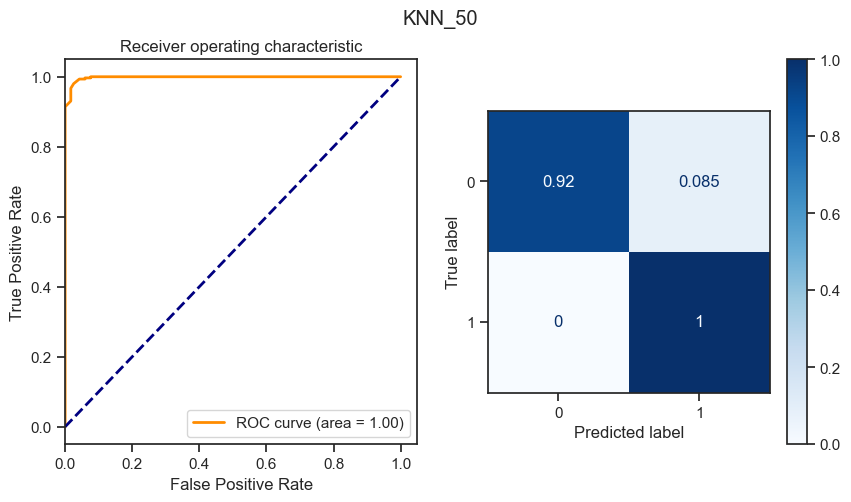

In [67]:
for model_name, model in clas_models_grid.items():
    clas_train_model(model_name, model, clasMetricLogger)

### Решение задачи регрессии

In [68]:
regr_models_grid = {'KNN_5':KNeighborsRegressor(n_neighbors=5), 
                    str('KNN_'+regr_gs_best_params_txt):regr_gs.best_estimator_}

In [69]:
for model_name, model in regr_models_grid.items():
    regr_train_model(model_name, model, regrMetricLogger)

KNN_5 	 MAE=1.959, MSE=8.097, R2=0.878
KNN_1 	 MAE=1.74, MSE=8.589, R2=0.871


## Формирование выводов о качестве построенных моделей на основе выбранных метрик. Результаты сравнения качества рекомендуется отобразить в виде графиков и сделать выводы в форме текстового описания. Рекомендуется построение графиков обучения и валидации, влияния значений гиперпарметров на качество моделей и т.д.

### Решение задачи классификации

In [70]:
# Метрики качества модели
clas_metrics = clasMetricLogger.df['metric'].unique()
clas_metrics

array(['precision', 'recall', 'f1', 'roc_auc'], dtype=object)

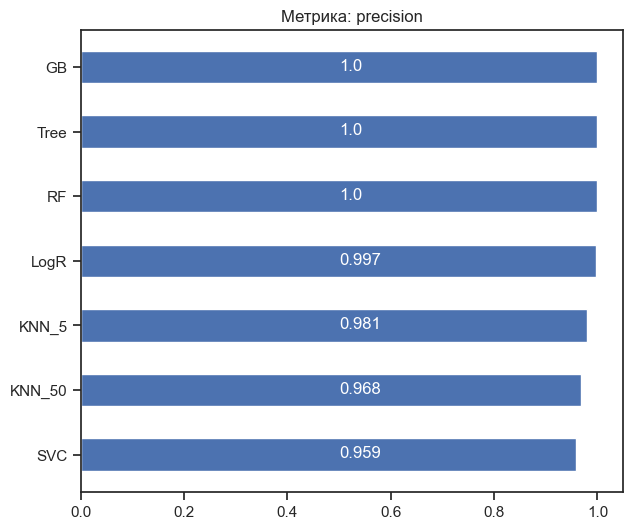

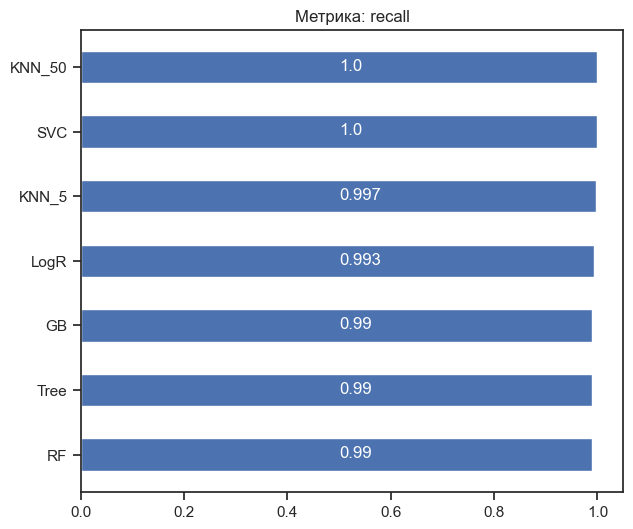

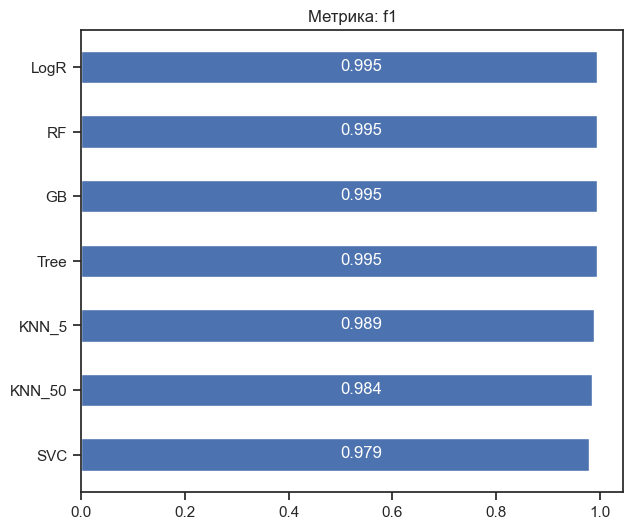

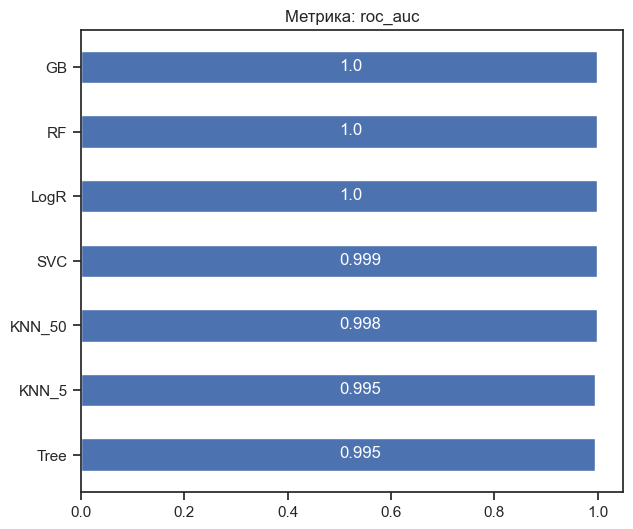

In [71]:
# Построим графики метрик качества модели
for metric in clas_metrics:
    clasMetricLogger.plot('Метрика: ' + metric, metric, figsize=(7, 6))

**Вывод: на основании трех метрик из четырех используемых,  лучшей оказалась модель логистической регрессии.**

### Решение задачи регрессии

In [72]:
# Метрики качества модели
regr_metrics = regrMetricLogger.df['metric'].unique()
regr_metrics

array(['MAE', 'MSE', 'R2'], dtype=object)

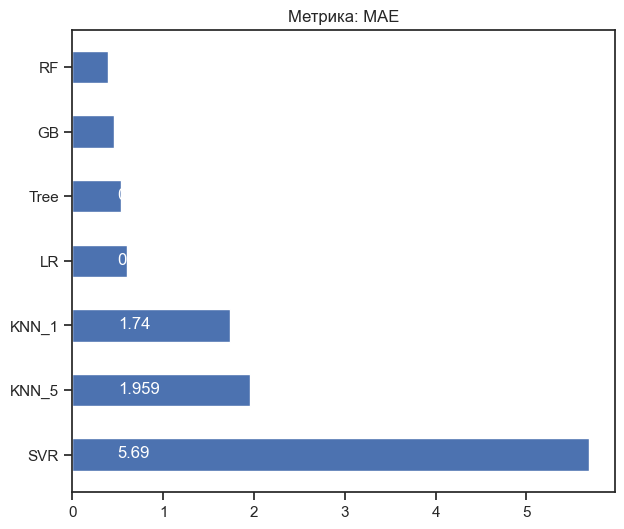

In [73]:
regrMetricLogger.plot('Метрика: ' + 'MAE', 'MAE', ascending=False, figsize=(7, 6))

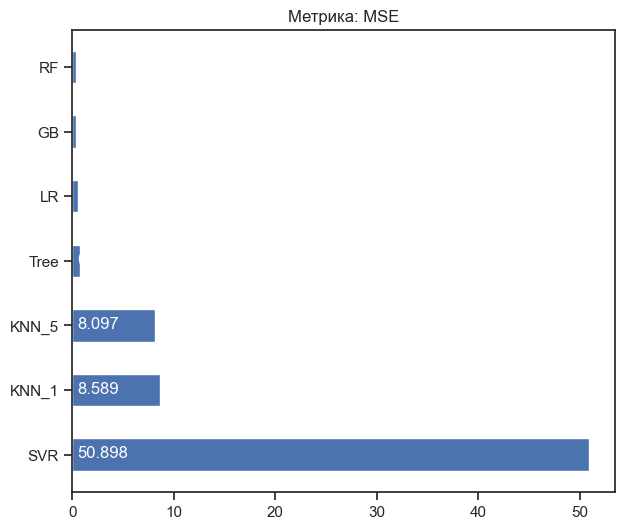

In [74]:
regrMetricLogger.plot('Метрика: ' + 'MSE', 'MSE', ascending=False, figsize=(7, 6))

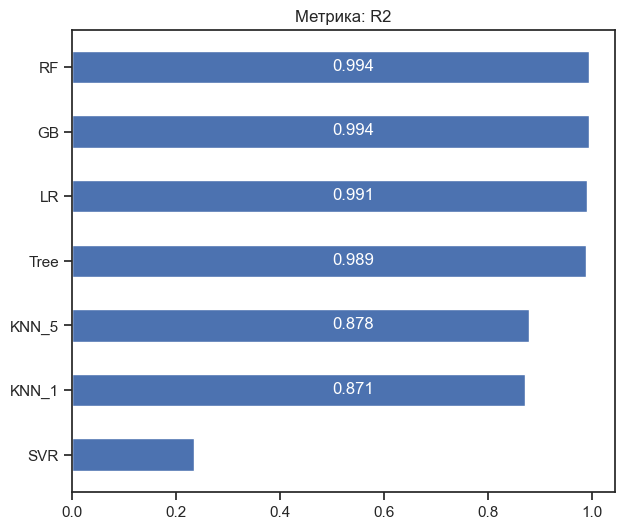

In [75]:
regrMetricLogger.plot('Метрика: ' + 'R2', 'R2', ascending=True, figsize=(7, 6))

**Вывод: лучшими оказались модели на основе линейной регресии и решающего дерева. При отдельных запусках вместо решающего дерева оказывается лучшей модель случайного леса.**